# Modelo A baseline

Este notebook entrena una primera versión del Modelo A limpio para estimar LT411.

El Modelo A no utiliza variables con riesgo de leakage:

- no usa LV411;
- no usa SP_LT411;
- no usa LT411 como variable de entrada;
- no usa lags derivados de LT411.

El objetivo de este notebook no es elegir el modelo final, sino comparar varios algoritmos de regresión como primera prueba base.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cargamos el dataset preparado para el Modelo A

df = pd.read_csv("data_limpio/features_modelo_A.csv")

df["Time"] = pd.to_datetime(df["Time"])

df.head()

,Time,bloque,LT411,DT412,INT_P101,FQC400_1_corr,FQC400_1_negativo_flag,FV400_1,PT442,PV442,...,TT415_delta_1,TT415_delta_6,PIT410_delta_1,PIT410_delta_6,PIT414_delta_1,PIT414_delta_6,DELTA_TT_delta_1,DELTA_TT_delta_6,DELTA_PIT_delta_1,DELTA_PIT_delta_6
0,2021-11-05 08:14:50,train,57.800925,1233.294202,58.336226,3040.664551,0,59.5,0.152228,0.0,...,0.000000,0.000000,-0.000223,-0.000350,-0.000810,-0.002257,0.000000,0.000000,-0.000587,-0.001907
1,2021-11-05 08:15:00,train,57.731480,1233.502551,58.472221,3031.220410,0,59.5,0.152402,0.0,...,-0.026042,-0.026042,-0.000318,0.000064,-0.001562,-0.002894,-0.008681,-0.008681,-0.001244,-0.002957
2,2021-11-05 08:15:10,train,58.622685,1233.294226,57.957175,3031.690015,0,59.5,0.152228,0.0,...,-0.060765,-0.086807,-0.000286,-0.000159,-0.000694,-0.004745,0.008681,0.000000,-0.000408,-0.004586
3,2021-11-05 08:15:20,train,59.343170,1233.385376,57.737267,3042.517261,0,59.5,0.152402,0.0,...,-0.026042,-0.112849,-0.000796,-0.001432,-0.000058,-0.004803,-0.013021,-0.013021,0.000738,-0.003371
4,2021-11-05 08:15:30,train,59.522568,1233.411389,57.974536,3053.772168,0,59.5,0.151881,0.0,...,-0.017361,-0.130211,-0.000223,-0.001751,-0.000521,-0.004167,0.013021,0.000000,-0.000298,-0.002416


In [3]:
# Separamos el dataset por bloques temporales

train = df[df["bloque"] == "train"].copy()

valid = df[df["bloque"] == "validacion"].copy()

test = df[df["bloque"] == "test"].copy()

In [4]:
# Definimos variables predictoras y target

columnas_no_modelo = ["Time", "bloque", "LT411"]

X_train = train.drop(columns=columnas_no_modelo)
y_train = train["LT411"]

X_valid = valid.drop(columns=columnas_no_modelo)
y_valid = valid["LT411"]

X_test = test.drop(columns=columnas_no_modelo)
y_test = test["LT411"]

In [5]:
# Revisamos tamaños de X e y

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (8551, 222)
y_train: (8551,)
X_valid: (8551, 222)
y_valid: (8551,)
X_test: (5701, 222)
y_test: (5701,)


In [6]:
# Importamos modelos y métricas de evaluación

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# Creamos una función simple para calcular métricas de regresión

def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    
    return mae, rmse, r2

## Primera prueba: Random Forest

Se entrena primero un `RandomForestRegressor` de forma individual para revisar su comportamiento con más detalle.

Este modelo sirve como primera referencia visual antes de comparar todos los algoritmos.

In [8]:
# Creamos un modelo Random Forest limitado para reducir sobreajuste

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [9]:
# Calculamos predicciones en train y validación

pred_train_rf = modelo_rf.predict(X_train)

pred_valid_rf = modelo_rf.predict(X_valid)

In [10]:
# Calculamos métricas del Random Forest

mae_train_rf, rmse_train_rf, r2_train_rf = calcular_metricas(y_train, pred_train_rf)

mae_valid_rf, rmse_valid_rf, r2_valid_rf = calcular_metricas(y_valid, pred_valid_rf)

print("Random Forest - Train")
print("MAE:", mae_train_rf)
print("RMSE:", rmse_train_rf)
print("R2:", r2_train_rf)

print("Random Forest - Validación")
print("MAE:", mae_valid_rf)
print("RMSE:", rmse_valid_rf)
print("R2:", r2_valid_rf)


Random Forest - Train
MAE: 0.9731676665855343
RMSE: 1.236840521320881
R2: 0.8831891618865553
Random Forest - Validación
MAE: 3.7788406258626406
RMSE: 5.540202112720648
R2: 0.19806174530270537


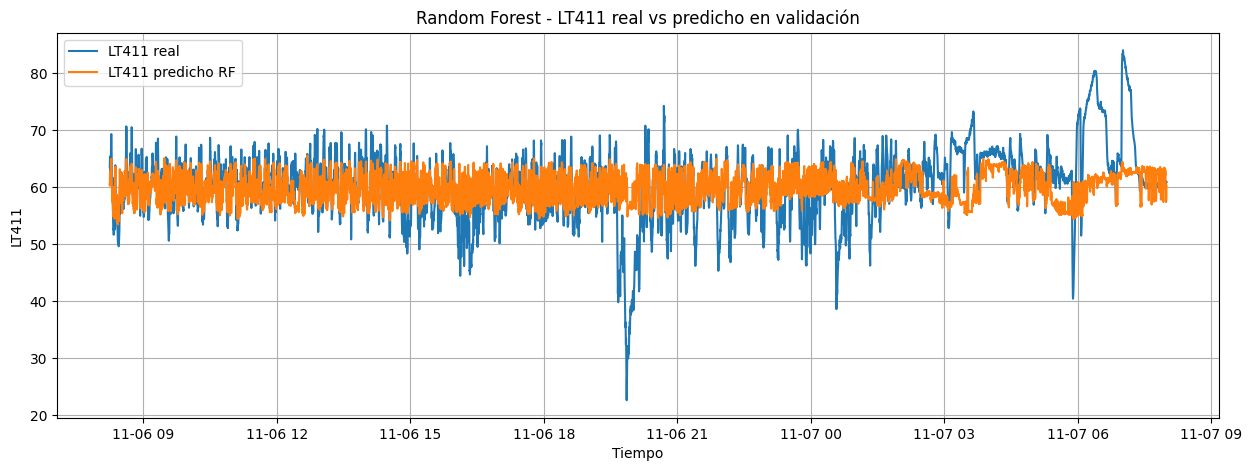

In [11]:
# Graficamos LT411 real frente a predicción en validación

plt.figure(figsize=(15, 5))

plt.plot(valid["Time"], y_valid, label="LT411 real")
plt.plot(valid["Time"], pred_valid_rf, label="LT411 predicho RF")

plt.title("Random Forest - LT411 real vs predicho en validación")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()

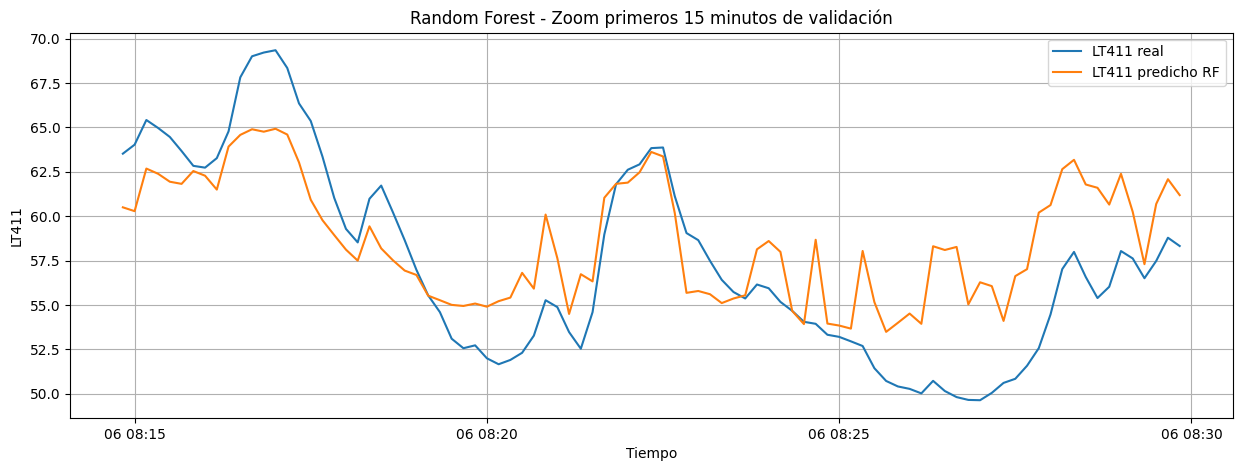

In [12]:
# Graficamos zoom de los primeros 15 minutos de validación

inicio_zoom_15min = valid["Time"].min()

fin_zoom_15min = inicio_zoom_15min + pd.Timedelta(minutes=15)

valid_zoom_15min = valid[
    (valid["Time"] >= inicio_zoom_15min) &
    (valid["Time"] <= fin_zoom_15min)
]

pred_valid_zoom_15min = pred_valid_rf[valid_zoom_15min.index - valid.index.min()]

plt.figure(figsize=(15, 5))

plt.plot(valid_zoom_15min["Time"], valid_zoom_15min["LT411"], label="LT411 real")
plt.plot(valid_zoom_15min["Time"], pred_valid_zoom_15min, label="LT411 predicho RF")

plt.title("Random Forest - Zoom primeros 15 minutos de validación")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()

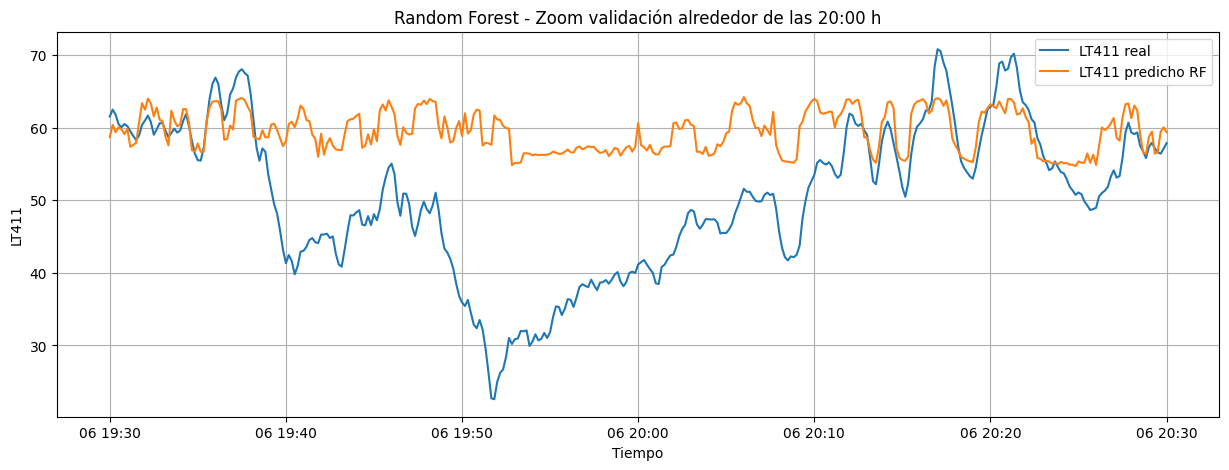

In [13]:
# Graficamos zoom alrededor de las 20:00 h en validación

inicio_zoom_20h = pd.Timestamp("2021-11-06 19:30:00")

fin_zoom_20h = pd.Timestamp("2021-11-06 20:30:00")

valid_zoom_20h = valid[
    (valid["Time"] >= inicio_zoom_20h) &
    (valid["Time"] <= fin_zoom_20h)
]

pred_valid_zoom_20h = pred_valid_rf[valid_zoom_20h.index - valid.index.min()]

plt.figure(figsize=(15, 5))

plt.plot(valid_zoom_20h["Time"], valid_zoom_20h["LT411"], label="LT411 real")
plt.plot(valid_zoom_20h["Time"], pred_valid_zoom_20h, label="LT411 predicho RF")

plt.title("Random Forest - Zoom validación alrededor de las 20:00 h")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()

## Residual y comportamiento en picos

Se calcula el residual del Random Forest en validación.

El residual se define como:

`LT411 real - LT411 predicho`

También se revisa si el modelo se comporta peor en zonas de pico, porque una predicción demasiado suavizada puede ocultar cambios rápidos de nivel.

In [14]:
# Creamos dataframe auxiliar con la predicción de Random Forest

valid_rf = valid.copy()

valid_rf["pred_RF"] = pred_valid_rf

In [15]:
# Calculamos el residual del Random Forest en validación

valid_rf["residual_RF"] = valid_rf["LT411"] - valid_rf["pred_RF"]

valid_rf.head()

,Time,bloque,LT411,DT412,INT_P101,FQC400_1_corr,FQC400_1_negativo_flag,FV400_1,PT442,PV442,...,PIT410_delta_1,PIT410_delta_6,PIT414_delta_1,PIT414_delta_6,DELTA_TT_delta_1,DELTA_TT_delta_6,DELTA_PIT_delta_1,DELTA_PIT_delta_6,pred_RF,residual_RF
8551,2021-11-06 08:14:50,validacion,63.518518,1224.075464,58.964119,3312.111816,0,59.700001,0.154861,0.0,...,0.000255,0.000318,0.000174,0.000694,0.000000e+00,-2.170181e-02,-0.000081,0.000376,60.497148,3.021370
8552,2021-11-06 08:15:00,validacion,64.024883,1226.471338,58.446180,3316.632861,0,59.700001,0.154832,0.0,...,-0.000382,0.001273,0.001042,0.000868,0.000000e+00,-8.680725e-03,0.001424,-0.000405,60.281618,3.743264
8553,2021-11-06 08:15:10,validacion,65.413772,1229.335901,57.499998,3314.397339,0,59.700001,0.155093,0.0,...,-0.001241,-0.001050,0.000694,0.001389,1.302109e-02,8.680725e-03,0.001936,0.002439,62.679245,2.734527
8554,2021-11-06 08:15:20,validacion,64.965276,1228.033826,59.464698,3310.663354,0,59.700001,0.155179,0.0,...,0.000955,-0.000095,0.000984,0.002141,7.105427e-14,1.302109e-02,0.000029,0.002237,62.385997,2.579279
8555,2021-11-06 08:15:30,validacion,64.458910,1226.236938,59.609374,3314.161475,0,59.700001,0.155208,0.0,...,0.002355,0.002069,-0.000116,0.003009,-1.302109e-02,9.947598e-14,-0.002471,0.000940,61.938634,2.520276


In [16]:
# Medimos error en los valores altos de LT411

umbral_pico = valid_rf["LT411"].quantile(0.90)

valid_rf["zona_pico"] = valid_rf["LT411"] >= umbral_pico

mae_picos = mean_absolute_error(
    valid_rf[valid_rf["zona_pico"]]["LT411"],
    valid_rf[valid_rf["zona_pico"]]["pred_RF"]
)

mae_no_picos = mean_absolute_error(
    valid_rf[~valid_rf["zona_pico"]]["LT411"],
    valid_rf[~valid_rf["zona_pico"]]["pred_RF"]
)

print("Umbral pico LT411:", umbral_pico)
print("MAE en picos:", mae_picos)
print("MAE fuera de picos:", mae_no_picos)

Umbral pico LT411: 66.49884033203126
MAE en picos: 9.596620339991208
MAE fuera de picos: 3.131664610879658


In [17]:
# Comparamos rango real y rango predicho en validación

print("LT411 real mínimo:", valid_rf["LT411"].min())
print("LT411 real máximo:", valid_rf["LT411"].max())

print("Predicción RF mínima:", valid_rf["pred_RF"].min())
print("Predicción RF máxima:", valid_rf["pred_RF"].max())

LT411 real mínimo: 22.586804962158208
LT411 real máximo: 84.07986068725587
Predicción RF mínima: 53.483564161074746
Predicción RF máxima: 65.56331012922898


## Lectura del Random Forest

El Random Forest sigue la tendencia general de LT411, pero la predicción aparece suavizada.

El rango predicho es más estrecho que el rango real de validación, lo que indica que el modelo amortigua picos y caídas.

Esto no invalida el modelo, pero muestra que todavía no captura bien los extremos de la señal.

## Comparativa inicial de modelos

Después de revisar Random Forest como primer modelo, se comparan cinco algoritmos de regresión:

- LinearRegression;
- Ridge;
- RandomForest;
- GradientBoosting;
- SVR.

Esta comparación sirve como baseline inicial. La optimización se realizará en un notebook posterior.

In [18]:
# Definimos modelos para comparar en validación

modelos = {
    "LinearRegression": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),
    
    "Ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),
    
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    
    "SVR": make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", C=10, epsilon=0.1)
    )
}

In [19]:
# Entrenamos modelos y evaluamos en train y validación

resultados = []

modelos_entrenados = {}

for nombre, modelo in modelos.items():
    
    modelo.fit(X_train, y_train)
    
    modelos_entrenados[nombre] = modelo
    
    pred_train = modelo.predict(X_train)
    pred_valid = modelo.predict(X_valid)
    
    mae_train, rmse_train, r2_train = calcular_metricas(y_train, pred_train)
    mae_valid, rmse_valid, r2_valid = calcular_metricas(y_valid, pred_valid)
    
    resultados.append({
        "modelo": nombre,
        "MAE_train": mae_train,
        "RMSE_train": rmse_train,
        "R2_train": r2_train,
        "MAE_valid": mae_valid,
        "RMSE_valid": rmse_valid,
        "R2_valid": r2_valid
    })

In [20]:
# Creamos tabla comparativa de modelos

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values("MAE_valid").reset_index(drop=True)

df_resultados

,modelo,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid
0,RandomForest,0.973168,1.236841,0.883189,3.778841,5.540202,0.198062
1,SVR,0.196455,0.316664,0.992343,4.022778,5.910424,0.087302
2,GradientBoosting,1.176621,1.466259,0.835836,4.158234,5.994281,0.061220
3,Ridge,1.149262,1.480243,0.832690,12.404893,21.124844,-10.659414
4,LinearRegression,1.147281,1.476307,0.833579,12.991876,22.354402,-12.056171


## Lectura de la comparativa inicial

En la primera comparativa del Modelo A, RandomForest obtiene el mejor MAE de validación, seguido muy de cerca por SVR y GradientBoosting.

Sin embargo, los tres modelos presentan un R² de validación bajo, por lo que no se considera cerrado el modelo final.

LinearRegression y Ridge quedan descartados como candidatos principales porque su error de validación es muy superior al resto.

A partir de este baseline, los modelos candidatos para optimización serán:

- RandomForest;
- GradientBoosting;
- SVR.

## Conclusiones del baseline

Este notebook compara cinco modelos de regresión para el Modelo A limpio.

Los modelos lineales, LinearRegression y Ridge, presentan mal comportamiento en validación y quedan descartados como candidatos principales.

RandomForest, SVR y GradientBoosting obtienen resultados mucho más razonables y pasan a la fase de optimización.

Este notebook se mantiene como baseline inicial. La selección del modelo candidato se realizará en el notebook de optimización, usando validación temporal y sin utilizar el Día 3 para elegir hiperparámetros.